Successfully loaded data from ../result/single_person_cat_history_with_reliability.csv


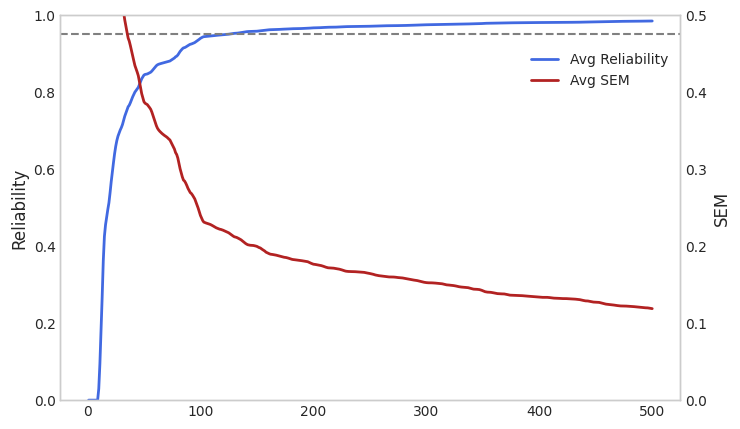

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import numpy as np
   
# =============================================================================
# 1. LOAD THE SIMULATION HISTORY
# =============================================================================

# Define the path to your results file
output_dir = "../result"
file_path = os.path.join(output_dir, "single_person_cat_history_with_reliability.csv")

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
except FileNotFoundError:
    print(f"ERROR: The file was not found at {file_path}")
    print("Please make sure you have run the previous simulation script successfully.")
    df = None

# =============================================================================
# 2. CALCULATE AVERAGE METRICS
# =============================================================================

if df is not None:
	# Find all SEM and reliability columns in the DataFrame
	sem_cols = [col for col in df.columns if col.startswith('sem_')]
	reliability_cols = [col for col in df.columns if col.startswith('reliability_')]

	# Calculate the average across all dimensions for each step (row)
	df['avg_sem'] = df[sem_cols].mean(axis=1)
	df['avg_reliability'] = df[reliability_cols].mean(axis=1)

	# Apply smoothing using rolling mean
	window_size = 5  # Define the window size for smoothing
	df['avg_sem_smooth'] = df['avg_sem'].rolling(window=window_size, min_periods=1).mean()
	df['avg_reliability_smooth'] = df['avg_reliability'].rolling(window=window_size, min_periods=1).mean()
	
	# =============================================================================
	# 3. PLOT THE RESULTS WITH FINAL AXIS ADJUSTMENT
	# =============================================================================

	# Create a figure and a primary y-axis for Reliability
	fig, ax1 = plt.subplots(figsize=(8, 5))  # Changed from (12, 7) to (8, 5)
	plt.style.use('seaborn-v0_8-whitegrid')

	# Plot Smoothed Average Reliability
	color = 'royalblue'
	# ax1.set_xlabel('Number of Items Answered', fontsize=12)
	ax1.set_ylabel('Reliability', fontsize=12)
	ax1.plot(df['step'], df['avg_reliability_smooth'], color=color, linewidth=2, label='Avg Reliability')
	ax1.tick_params(axis='y')
	ax1.set_ylim(0, 1.0)

	# Add a horizontal line for a common reliability target
	ax1.axhline(y=0.95, color='gray', linestyle='--')
	
	# Create a secondary y-axis for SEM
	ax2 = ax1.twinx()
	ax2.set_ylim(0, 0.5)
	color = 'firebrick'
	ax2.set_ylabel('SEM', fontsize=12)
	ax2.plot(df['step'], df['avg_sem_smooth'], color=color, linewidth=2, label='Avg SEM')
	ax2.tick_params(axis='y')

	# Synchronize the ticks on both y-axes
	ax1.yaxis.set_major_locator(mticker.LinearLocator(numticks=6))
	ax2.yaxis.set_major_locator(mticker.LinearLocator(numticks=6))
	ax1.grid(False)
	ax2.grid(False)

	fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.83))
	plt.savefig("../result/reliability-SEM-CAT.png", dpi=300, bbox_inches='tight')
	plt.show()